In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [3]:
import os 

In [54]:
P3hobodf = pd.read_csv('P3_current.csv')
P3hobodf = P3hobodf.dropna()
P3hobodf["Date-Time"] = pd.to_datetime(P3hobodf["Date-Time"]) 
P3hobodf.index = pd.DatetimeIndex(P3hobodf["Date-Time"]) 

In [55]:
P3filtered = hampel(P3hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [56]:
P3filtered = pd.DataFrame(P3filtered.filtered_data.to_numpy(), index=P3hobodf.index)

In [57]:
P3filteredSPC = hampel(P3hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)
P3filteredSPC = pd.DataFrame(P3filteredSPC.filtered_data.to_numpy(), index=P3hobodf.index)

In [58]:
P3hobodf["FilteredTemp"] = P3filtered
P3hobodf["FilteredSPC"] = P3filteredSPC

In [59]:
P3hobodf = P3hobodf[1:]

In [60]:
# manual data 
P3mandf = pd.read_csv("Well_Sampling_Data_ALL - P3.csv", index_col=False) #Well_Sampling_Data_P3.csv is a placeholder for the csv file with the field measurements from the piezometer of interest. mandf is the placeholder for the dataframe with all of the manual field measurements. 
P3mandf["Date"] = pd.to_datetime(P3mandf["Date"]) #converts the manual date-time values to pandas datetime format. 

In [61]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDamTemp.csv")
weatherdf["Date"] = pd.to_datetime(weatherdf["Date"])

In [62]:
#reading C3 continuous data
C3hobodf = pd.read_csv("Mdstrm_current.csv") 
C3hobodf["Date-Time"] = pd.to_datetime(C3hobodf["Date-Time"]) 
C3hobodf.index = pd.DatetimeIndex(C3hobodf["Date-Time"])

In [63]:
#filtering the C3 data for the outlier spikes where the hobo probe was removed from the piezometer
C3filtered = hampel(C3hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [64]:
C3filtered = pd.DataFrame(C3filtered.filtered_data.to_numpy(), index=C3hobodf.index)

In [65]:
C3filteredSPC = hampel(C3hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)
C3filteredSPC = pd.DataFrame(C3filteredSPC.filtered_data.to_numpy(), index=C3hobodf.index)

In [66]:
C3hobodf["FilteredTemp"] = C3filtered
C3hobodf["FilteredSPC"] = C3filteredSPC

In [67]:
C3hobodf.head()

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,,
2026-07-02 16:15:00,2026-07-02 16:15:00,19.036930,547.234863,625.571777,0.301681,355.702637,19.036930,625.571777
2026-07-02 16:30:00,2026-07-02 16:30:00,18.379948,549.983521,638.788574,0.307832,357.489288,18.379948,638.788574
2026-07-02 16:45:00,2026-07-02 16:45:00,18.626682,543.735352,627.753662,0.302518,353.427979,18.626682,627.753662
2026-07-02 17:00:00,2026-07-02 17:00:00,18.662357,543.779663,627.262329,0.302296,353.456757,18.662357,627.262329
2026-07-02 17:15:00,2026-07-02 17:15:00,18.647495,543.129883,626.738464,0.302028,353.034424,18.647495,626.738464


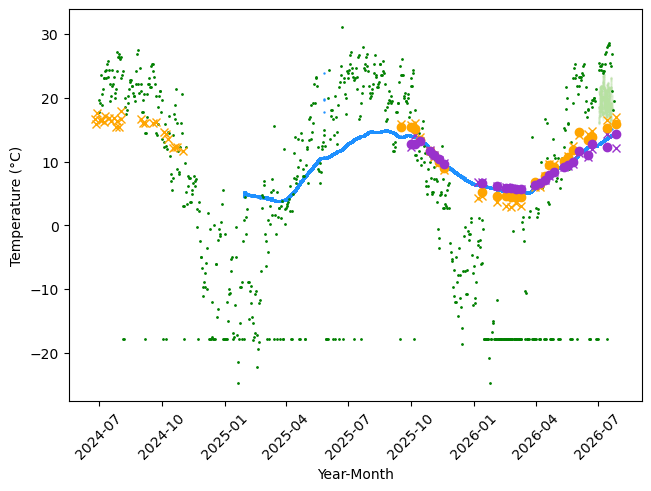

In [68]:
#creating the plot
P3mandf.columns = P3mandf.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe.  


fig, ax = plt.subplots(layout='constrained')
#ax.plot(date1, filteredhobo, color="blue", label = "HOBO continuous temperature")
ax.scatter(P3hobodf.index, P3hobodf.FilteredTemp, color="dodgerblue", s = 0.5, label = "P3 continuous temperature")
ax.scatter(C3hobodf.index, C3hobodf.FilteredTemp, color = "xkcd:light grey green", alpha = 0.2, s = 0.2, label = "C3 continuous temperature")
ax.plot(P3mandf.Date, P3mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping") #each variable in the manual field measurmemts data set is called by their column instead of naming each variable. The placeholders here are mandf.Date (which you should replace with the nameofdataframe.nameofcolumnfortime), mandf.loc[:,"Temp top before"] (which you should replace with nameofdataframe.loc[:, "Name of column for parameter"], and manual temperature at top before pumping (which you should replace with the name of the data for the legend). 
ax.plot(P3mandf.Date, P3mandf.loc[:,"Temp bottom before"], 'x', color = "darkorchid", label = "manual temperature at bottom before pumping")
ax.plot(P3mandf.Date, P3mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(P3mandf.Date, P3mandf.loc[:,"Temp bottom after"], 'o', color = "darkorchid", label = "manual temperature at bottom after pumping")
ax.scatter(weatherdf.Date, weatherdf.loc[:,"MeanTempC"], color = "green", s = 1, label = "air temperature")
# ax.plot(C3hobodfdate, C3filteredhobo, color = "xkcd:light grey green", label = "C3 continuous temperature data")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Temperature (°C)") #Temperature (°C) is a placeholder.
# plt.xlim((pd.to_datetime("2025-11-18 06"), pd.to_datetime("2025-11-18 16")))
# plt.ylim((0, 20))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-06")))
# plt.ylim((6, 8))

# fig.legend(loc='outside upper right') #this line puts legend outside of graph, squishes it down, but is not awful. Run with # in front to see the graph at its default dimensions.

plt.show()

In [69]:
#P3 SPC

In [70]:
P3hobodf = P3hobodf[1:] # the first value in after running the hampel filter is too low (because the filter pads the data set with zeros, thus replacing the first value with a number that is a reasonable average if you include the zeros). So, I remove it here. 


In [71]:
# # add C3 SPC for comparison

# creek = pd.read_csv('P3_creek_cond_current.csv')
# creek['Date-Time'] = pd.to_datetime(creek['Date-Time'])
# creek.index = pd.DatetimeIndex(creek['Date-Time']) 
# creekfiltered = hampel(creek["Specific Conductivity"], window_size=6, n_sigma=1.5)
# creekfiltered = pd.DataFrame(creekfiltered.filtered_data.to_numpy(), index=creek.index)
# creek["FilteredSPC"] = creekfiltered
# creek.head()

In [72]:
P3hobodf = P3hobodf[:51394] #removes the last point (too low)

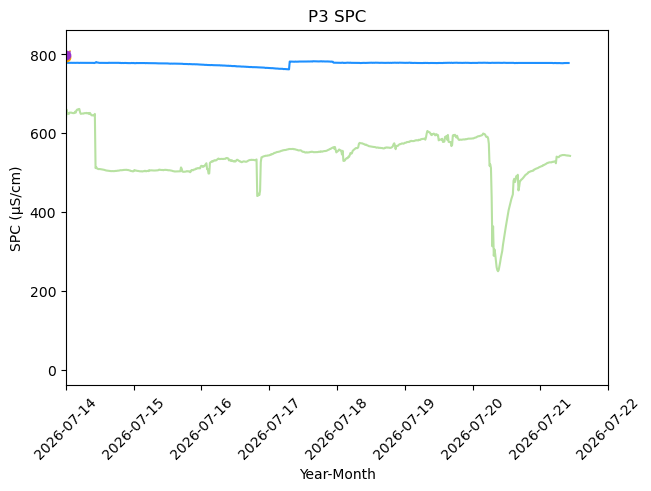

In [73]:

P3hobodate = P3hobodf["Date-Time"]
P3slicedhobodate = P3hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.plot(P3hobodf.index, P3hobodf.FilteredSPC, color="dodgerblue", label = "P3 continuous SPC")
ax.plot(P3mandf.Date, P3mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(P3mandf.Date, P3mandf.loc[:,"SPC bottom before"], 'x', color = "darkorchid", label = "manual SPC at bottom before pumping")
ax.plot(P3mandf.Date, P3mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(P3mandf.Date, P3mandf.loc[:,"SPC bottom after"], 'o', color = "darkorchid", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("P3 SPC")

# add C3 SPC for comparison
ax.plot(C3hobodf.index, C3hobodf.FilteredSPC, color = "xkcd:light grey green", label = 'creek SPC at P3')
# plt.ylim((700, 750))
plt.xlim((pd.to_datetime("2026-07-14"), pd.to_datetime("2026-07-22")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
# fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

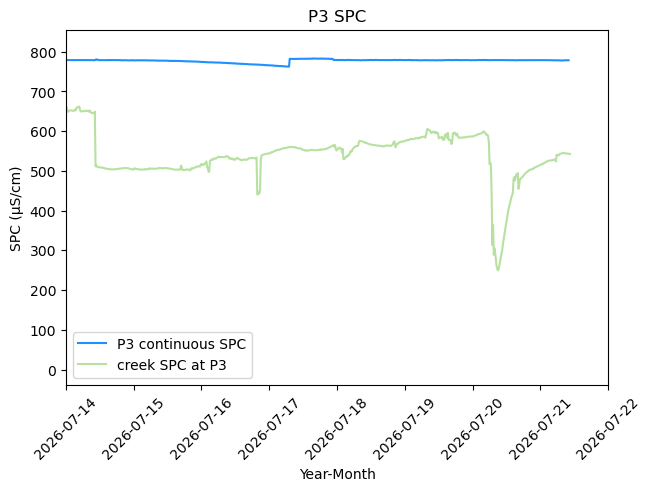

In [74]:
fig, ax = plt.subplots(layout='constrained')
ax.plot(P3hobodf.index, P3hobodf.FilteredSPC, color="dodgerblue", label = "P3 continuous SPC")
ax.plot(C3hobodf.index, C3hobodf.FilteredSPC, color = "xkcd:light grey green", label = 'creek SPC at P3')
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("P3 SPC")
plt.xlim((pd.to_datetime("2026-07-14"), pd.to_datetime("2026-07-22")))
ax.legend()

plt.show()

In [75]:
precip = pd.read_csv("NOAAFaribaultPrecipitation.csv")
precip["Date"] = pd.to_datetime(precip["Date"])
precip = precip[precip["PrecipitationCM"] != 0]

In [76]:
precip.head()

,Date,PrecipitationIN,PrecipitationCM
0,2024-07-23,0.29,0.7366
1,2024-07-24,0.02,0.0508
7,2024-07-30,0.02,0.0508
9,2024-08-01,2.60,6.6040
10,2024-08-02,0.10,0.2540


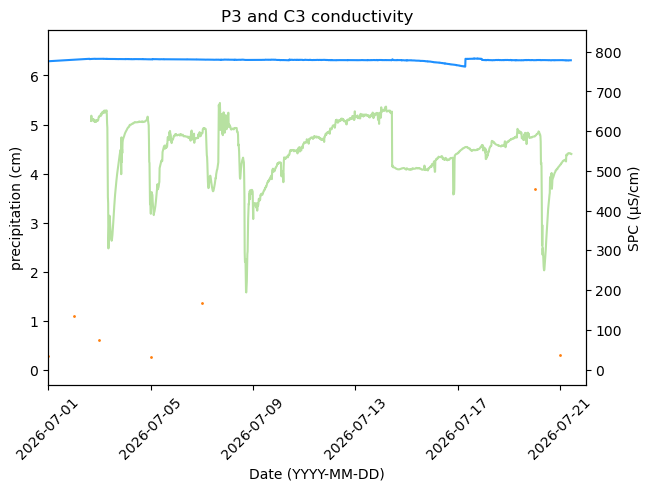

In [77]:
fig, ax1 = plt.subplots(layout='constrained')
ax1.set_xlabel('Date (YYYY-MM-DD)')
ax1.set_ylabel('precipitation (cm)')
rain = ax1.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, s= 1, color = 'tab:orange', label = "precipitation (cm)")
# ax.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], color = "green", s = 1, label = "air temperature")

ax1.tick_params(axis='x', rotation=45)
# ax1.set_ylim(0, 3)


ax2 = ax1.twinx() 
ax2.set_ylabel('SPC (µS/cm)') 
P3 = ax2.plot(P3hobodf.index, P3hobodf.FilteredSPC, color="dodgerblue", label = "P3 continuous SPC")
C3 = ax2.plot(C3hobodf.index, C3hobodf.FilteredSPC,  color = "xkcd:light grey green", label = 'creek SPC at P3')
# ax2.set_ylim(0, 1200)
ax2.set_xlim((pd.to_datetime("2026-07-01"), pd.to_datetime("2026-07-22")))

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.title("P3 and C3 conductivity")
# leg = rain + C3 + C1
# labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs)

# plt.xlim(pd.to_datetime("2025-04"), pd.to_datetime("2025-05"))

plt.show();

In [78]:
import colorsys

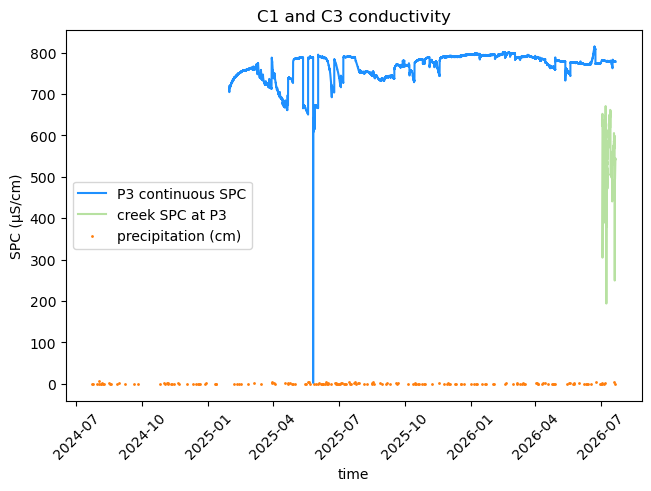

In [79]:
#this is just to make a legend that works
fig, ax = plt.subplots(layout='constrained')
ax.set_xlabel('time')
ax.set_ylabel('SPC (µS/cm)')
P3 = ax.plot(P3hobodf.index, P3hobodf.FilteredSPC, color="dodgerblue", label = "P3 continuous SPC")
C3 = ax.plot(C3hobodf.index, C3hobodf.FilteredSPC,  color = "xkcd:light grey green", label = 'creek SPC at P3')
ax.tick_params(axis='x', rotation=45)

rain = ax.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, s= 1, color = 'tab:orange', label = "precipitation (cm)")
# ax2.plot((precip.Date, precip.PrecipitationCM))
# ax2.tick_params(axis='y', labelcolor=color)
# ax.twinx.plot(precip.Date, precip.PrecipitationCM, color = "bisque", alpha = 0.5, label = "precipitation (cm)")

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.title("C1 and C3 conductivity")

plt.legend()
# plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime("2025-04-03"))

plt.show();

In [80]:
# resampling spc so that I can plot creek against piezometer
# P3hobodf.set_index('Date-Time', inplace=True)
# P3hobodf = P3hobodf.resample('D').mean()

In [81]:
P3hobodf

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,,
2025-01-29 17:47:59,2025-01-29 17:47:59,4.568516,410.281891,718.609192,0.325706,266.683228,4.568516,718.609192
2025-01-29 18:02:59,2025-01-29 18:02:59,4.600956,410.486023,718.109863,0.325563,266.815918,4.600956,718.109863
2025-01-29 18:17:59,2025-01-29 18:17:59,4.623661,410.468811,717.481262,0.325331,266.804718,4.623661,717.481262
2025-01-29 18:32:59,2025-01-29 18:32:59,4.620426,410.234497,717.156860,0.325169,266.652405,4.620426,717.156860
2025-01-29 18:47:59,2025-01-29 18:47:59,4.626896,410.029236,716.627808,0.324938,266.518982,4.626896,716.627808
...,...,...,...,...,...,...,...,...
2026-07-21 09:00:00,2026-07-21 09:00:00,14.161991,600.952026,778.030334,0.373149,390.618805,14.161991,778.242188
2026-07-21 09:15:00,2026-07-21 09:15:00,14.161991,601.178040,778.322937,0.373294,390.765717,14.161991,778.322937
2026-07-21 09:30:00,2026-07-21 09:30:00,14.158970,601.065063,778.240601,0.373250,390.692291,14.161991,778.240601


In [82]:
# C3hobodf.set_index('Date-Time', inplace=True)
# C3hobodf = C3hobodf.resample('D').mean()

In [83]:
C3hobodf

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,,
2026-07-02 16:15:00,2026-07-02 16:15:00,19.036930,547.234863,625.571777,0.301681,355.702637,19.036930,625.571777
2026-07-02 16:30:00,2026-07-02 16:30:00,18.379948,549.983521,638.788574,0.307832,357.489288,18.379948,638.788574
2026-07-02 16:45:00,2026-07-02 16:45:00,18.626682,543.735352,627.753662,0.302518,353.427979,18.626682,627.753662
2026-07-02 17:00:00,2026-07-02 17:00:00,18.662357,543.779663,627.262329,0.302296,353.456757,18.662357,627.262329
2026-07-02 17:15:00,2026-07-02 17:15:00,18.647495,543.129883,626.738464,0.302028,353.034424,18.647495,626.738464
...,...,...,...,...,...,...,...,...
2026-07-21 09:30:00,2026-07-21 09:30:00,18.287785,467.058319,543.695740,0.260848,303.587891,18.287785,543.695740
2026-07-21 09:45:00,2026-07-21 09:45:00,18.356144,467.302277,543.072205,0.260580,303.746460,18.356144,543.072205
2026-07-21 10:00:00,2026-07-21 10:00:00,18.362095,467.594574,543.333069,0.260712,303.936462,18.362095,543.333069


In [84]:
P3hobodf = P3hobodf.tail(len(C3hobodf))

In [85]:
print("X shape:", C3hobodf.FilteredSPC.shape, "Total size:", C3hobodf.FilteredSPC.size)
print("Y shape:", P3hobodf.FilteredSPC.shape, "Total size:", P3hobodf.FilteredSPC.size)

X shape: (1802,) Total size: 1802
Y shape: (1802,) Total size: 1802


In [86]:
z = np.polyfit(C3hobodf.FilteredSPC, P3hobodf.FilteredSPC, 1)
p = np.poly1d(z)

[]

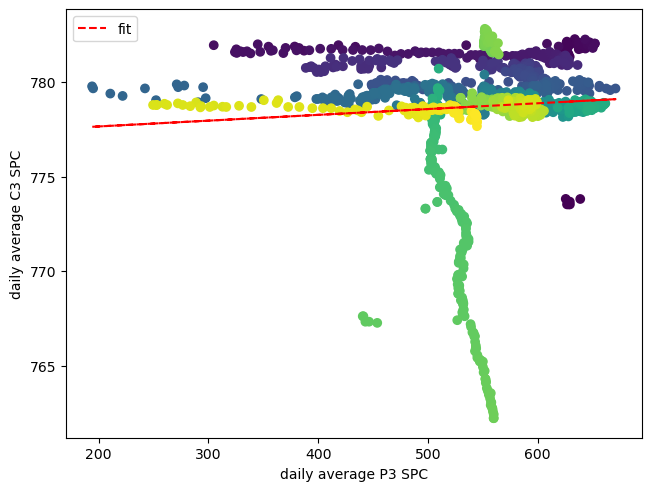

In [87]:
fig, ax = plt.subplots(layout='constrained')

ax.scatter(C3hobodf.FilteredSPC, P3hobodf.FilteredSPC, c = C3hobodf.index, cmap = 'viridis')
ax.plot(C3hobodf.FilteredSPC, p(C3hobodf.FilteredSPC), color = 'r', linestyle = 'dashed', label = 'fit')


plt.ylabel("daily average C3 SPC")
plt.xlabel("daily average P3 SPC")

ax.legend()

plt.plot()

In [88]:
# resampling spc so that I can plot creek against piezometer
P3hobodf.set_index('Date-Time', inplace=True)
P3hobodf.index = P3hobodf.index.round('15min')

In [89]:
C3hobodf.set_index('Date-Time', inplace=True)
C3hobodf.index = C3hobodf.index.round('15min')

In [94]:
P3hobodf = P3hobodf.reindex_like(C3hobodf, method = None)

In [98]:
print("X shape:", C3hobodf.FilteredSPC.shape, "Total size:", C3hobodf.FilteredSPC.size)
print("Y shape:", C3hobodf.FilteredSPC.shape, "Total size:", C3hobodf.FilteredSPC.size)

X shape: (1802,) Total size: 1802
Y shape: (1802,) Total size: 1802


In [101]:
C3hobodf['mos'] = C3hobodf.index.to_period('M')

In [102]:
C3hobodf['mos'] = C3hobodf.mos.dt.strftime('%B %Y')

In [104]:
P3hobodf['mos'] = P3hobodf.index.to_period('M')

In [105]:
P3hobodf['mos'] = P3hobodf.mos.dt.strftime('%B %Y')

In [ ]:
#this is dumb they are all from the same month

[]

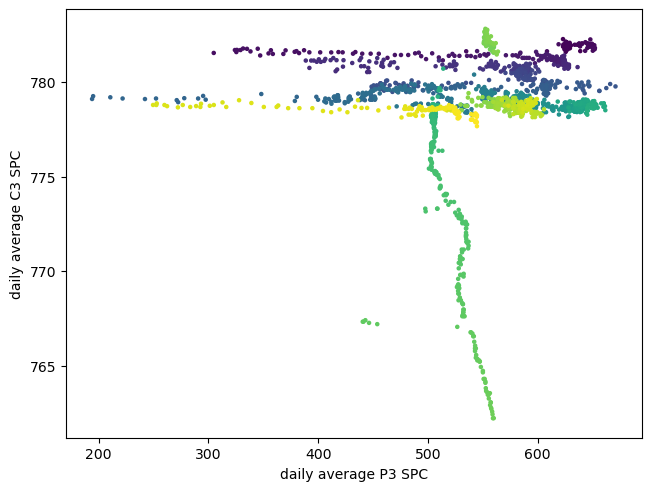

In [109]:
fig, ax = plt.subplots(layout='constrained')

ax.scatter(C3hobodf.FilteredSPC, P3hobodf.FilteredSPC, s = 5,  c = C3hobodf.index, cmap = 'viridis')
# ax.plot(C3hobodf.FilteredSPC, p(C3hobodf.FilteredSPC), color = 'r', linestyle = 'dashed', label = 'fit')


plt.ylabel("daily average C3 SPC")
plt.xlabel("daily average P3 SPC")

# ax.legend()

plt.plot()